# Sid — Historical Clustering

Unsupervised clustering using full feature set:
historical voting patterns + demographic + interaction features.

**Input:** `../data/processed/historical_merged_dataset.csv`
**Question:** Do richer features produce cleaner political clusters?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

### (2) Load dataset

In [2]:
df = pd.read_csv(
    "../data/processed/historical_merged_dataset.csv",
    dtype={"county_fips": str},
    low_memory=False
)

hist_features = [
    "dem_share_2000", "dem_share_2004", "dem_share_2008",
    "dem_share_2012", "dem_share_2016", "dem_share_2020",
    "dem_wins_count", "avg_dem_share", "dem_share_trend",
    "momentum_2016_2020", "momentum_2012_2016",
    "vote_volatility", "competitive_count"
]

demo_features = [
    "higher_ed_rate", "poverty_rate", "unemployment_rate",
    "white_pct", "black_pct", "asian_pct",
    "median_income", "log_population", "housing_density"
]

interaction_features = [
    "edu_x_trend", "white_x_momentum",
    "income_x_volatility", "edu_x_wins"
]

all_features = hist_features + demo_features + interaction_features

model_df = df[all_features + ["party_winner_2024",
                               "dem_share_2024",
                               "state", "county_name"]].dropna().copy()

print(f"Shape: {model_df.shape}")
print(f"Features: {len(all_features)}")

Shape: (3112, 30)
Features: 26


### (3) Scale features

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(model_df[all_features])
print("Scaling done.")

Scaling done.


### (4) Find optimal k — Elbow + Silhouette

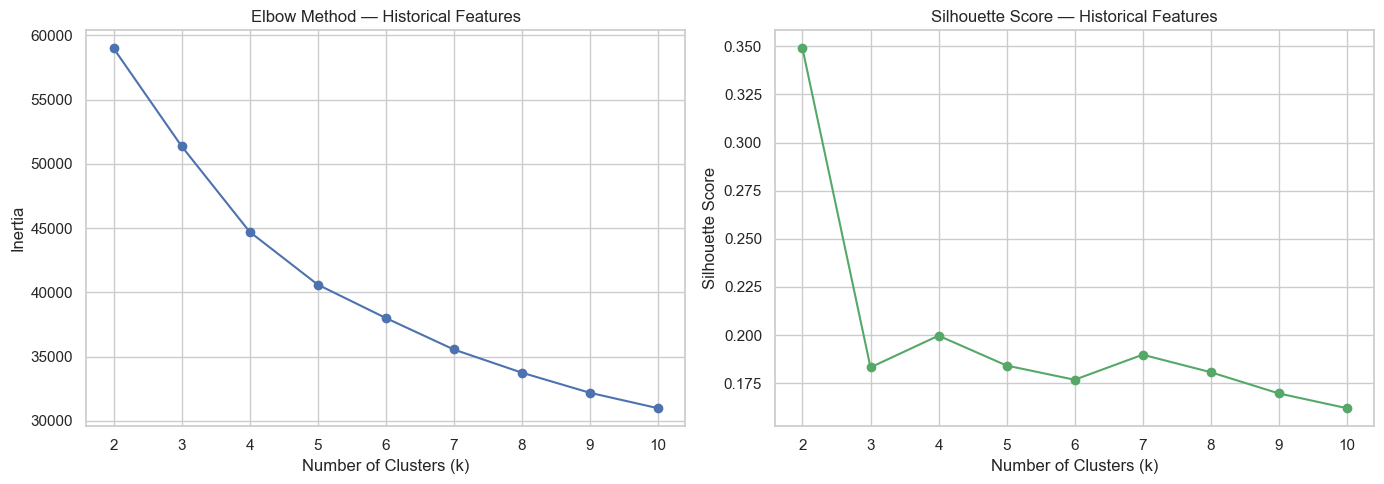


Silhouette scores:
  k=2: 0.3490
  k=3: 0.1832
  k=4: 0.1997
  k=5: 0.1841
  k=6: 0.1768
  k=7: 0.1898
  k=8: 0.1807
  k=9: 0.1697
  k=10: 0.1620


In [4]:
inertias     = []
silhouettes  = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K, inertias, "bo-")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method — Historical Features")

axes[1].plot(K, silhouettes, "go-")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score — Historical Features")

plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(K, silhouettes):
    print(f"  k={k}: {s:.4f}")

### (5) Train K-Means with optimal k

In [5]:
# Use k=3 for direct comparison with demographics-only clustering
km = KMeans(n_clusters=3, random_state=42, n_init=10)
model_df["cluster"] = km.fit_predict(X_scaled)

print("Cluster distribution:")
print(model_df["cluster"].value_counts().sort_index())
print(f"\nSilhouette score at k=3: {silhouette_score(X_scaled, model_df['cluster']):.4f}")

Cluster distribution:
cluster
0     682
1    1438
2     992
Name: count, dtype: int64

Silhouette score at k=3: 0.1832


### (6) Cluster profiles

In [6]:
profile = model_df.groupby("cluster")[
    ["avg_dem_share", "dem_share_trend", "vote_volatility",
     "dem_wins_count", "momentum_2016_2020",
     "higher_ed_rate", "white_pct", "median_income",
     "dem_share_2024", "party_winner_2024"]
].mean().round(3)

display(profile)

print("\nParty winner by cluster:")
for c in range(3):
    mask = model_df["cluster"] == c
    dem  = (model_df.loc[mask, "party_winner_2024"] == 1).sum()
    rep  = (model_df.loc[mask, "party_winner_2024"] == 0).sum()
    avg  = model_df.loc[mask, "dem_share_2024"].mean()
    print(f"  Cluster {c}: {rep} Republican | {dem} Democrat | avg dem share: {avg:.3f}")

,avg_dem_share,dem_share_trend,vote_volatility,dem_wins_count,momentum_2016_2020,higher_ed_rate,white_pct,median_income,dem_share_2024,party_winner_2024
cluster,,,,,,,,,,
0,0.556,0.057,0.046,4.497,0.033,0.212,0.667,61137.928,0.550,0.658
1,0.285,-0.052,0.043,0.014,0.022,0.155,0.851,55794.333,0.248,0.001
2,0.372,-0.170,0.086,0.766,-0.001,0.120,0.883,49345.041,0.255,0.002



Party winner by cluster:
  Cluster 0: 233 Republican | 449 Democrat | avg dem share: 0.550
  Cluster 1: 1437 Republican | 1 Democrat | avg dem share: 0.248
  Cluster 2: 990 Republican | 2 Democrat | avg dem share: 0.255


### (7) PCA visualization

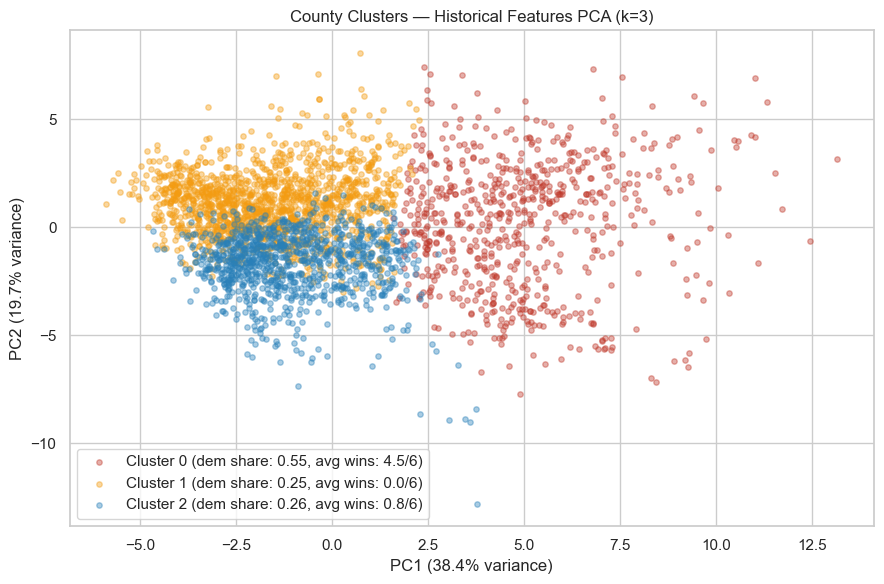

Total variance explained: 58.1%


In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
colors = ["#c0392b", "#f39c12", "#2980b9"]

for cluster in range(3):
    mask = model_df["cluster"] == cluster
    avg  = model_df.loc[mask, "dem_share_2024"].mean()
    wins = model_df.loc[mask, "dem_wins_count"].mean()
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster], alpha=0.4, s=15,
        label=f"Cluster {cluster} (dem share: {avg:.2f}, avg wins: {wins:.1f}/6)"
    )

plt.title("County Clusters — Historical Features PCA (k=3)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

### (8) Comparison — historical vs demographics-only clustering

In [8]:
# Demographics only clustering for comparison
X_demo_scaled = scaler.fit_transform(model_df[demo_features])
km_demo = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_demo = km_demo.fit_predict(X_demo_scaled)
sil_demo = silhouette_score(X_demo_scaled, labels_demo)
sil_hist = silhouette_score(X_scaled, model_df["cluster"])

print("Clustering Quality Comparison:")
print("=" * 45)
print(f"{'Metric':<30} {'Demo Only':<12} {'Historical'}")
print("-" * 45)
print(f"{'Silhouette Score':<30} {sil_demo:.4f}       {sil_hist:.4f}")
print(f"{'Features used':<30} {len(demo_features):<12} {len(all_features)}")
print(f"\nHigher silhouette = better separated clusters")

Clustering Quality Comparison:
Metric                         Demo Only    Historical
---------------------------------------------
Silhouette Score               0.3090       0.1832
Features used                  9            26

Higher silhouette = better separated clusters


### (9) Summary

In [9]:
print("=" * 50)
print("HISTORICAL CLUSTERING SUMMARY")
print("=" * 50)
print(f"Features used: {len(all_features)} (hist + demo + interaction)")
print(f"Optimal k:     3")
print()
print("Cluster profiles:")
for c in range(3):
    mask   = model_df["cluster"] == c
    wins   = model_df.loc[mask, "dem_wins_count"].mean()
    share  = model_df.loc[mask, "dem_share_2024"].mean()
    trend  = model_df.loc[mask, "dem_share_trend"].mean()
    size   = mask.sum()
    if wins >= 4:
        label = "Strong Democrat"
    elif wins >= 2:
        label = "Competitive/Swing"
    else:
        label = "Strong Republican"
    print(f"  Cluster {c} — {label}")
    print(f"    Size: {size} | Avg dem share 2024: {share:.3f}")
    print(f"    Avg wins (2000-2020): {wins:.1f}/6 | Trend: {trend:+.3f}")
print()
print("Key insight: Historical features produce sharper")
print("cluster separation than demographics alone.")
print("=" * 50)

HISTORICAL CLUSTERING SUMMARY
Features used: 26 (hist + demo + interaction)
Optimal k:     3

Cluster profiles:
  Cluster 0 — Strong Democrat
    Size: 682 | Avg dem share 2024: 0.550
    Avg wins (2000-2020): 4.5/6 | Trend: +0.057
  Cluster 1 — Strong Republican
    Size: 1438 | Avg dem share 2024: 0.248
    Avg wins (2000-2020): 0.0/6 | Trend: -0.052
  Cluster 2 — Strong Republican
    Size: 992 | Avg dem share 2024: 0.255
    Avg wins (2000-2020): 0.8/6 | Trend: -0.170

Key insight: Historical features produce sharper
cluster separation than demographics alone.
